## Building SLM from Scratch

## Step 1: Import the Dataset

In [2]:
!pip install datasets

### Cleaning Pipeline

The raw **TinyStories** dataset contains approximately **5M stories** generated by both GPT-3.5 and GPT-4. We use the **GPT-4-only subset**, containing **2,745,330 stories**, and apply the following cleaning steps to obtain a high-quality training corpus.

#### 1. Unicode Normalization

The following normalization rules are applied:

* Curly quotes are converted to straight quotes.
* Em/en dashes are converted to hyphens.
* Ellipsis characters are converted to `...`.
* Stray backslashes are removed.
* Multiple consecutive spaces are collapsed into a single space.

#### 2. Non-ASCII Character Rejection

Stories containing any character outside **printable ASCII (codes 32–127)** are discarded.

Newline characters (`\n`, ASCII code 10) are allowed because they can be used as paragraph separators.

#### 3. Banned Character Rejection

Stories containing characters associated with formatting artifacts, HTML tags, chat templates, or code contamination are discarded.

The banned characters are:

```text
< > / * = _ & @ ~ # % [ ] + ( )
```

#### 4. Minimum Length Filtering

Stories containing fewer than **100 characters** are discarded.

This removes fragments, empty entries, and stories that are too short to provide meaningful training examples.

#### 5. Ending Punctuation

Stories are required to end with one of the following punctuation marks:

```text
. ! " ?
```

This helps ensure that each story represents a complete textual sequence rather than an incomplete fragment.

---

#### Rejection Breakdown

| Reason                       |      Count |
| ---------------------------- | ---------: |
| Non-ASCII characters         |      1,282 |
| Banned characters            |        720 |
| Too short (< 100 characters) |        238 |
| Bad ending punctuation       |     10,456 |
| **Total rejected**           | **12,696** |

Only approximately **0.46%** of the GPT-4 stories are rejected during cleaning, indicating that the original GPT-4 subset is already a relatively clean dataset.

---

#### Character Inventory

After cleaning, the dataset contains **74 unique ASCII characters**.

The dataset contains only printable ASCII characters (with newline characters allowed as paragraph separators), with no Unicode characters, control characters, or other special symbols.

The character set is:

```text
abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ
\n !"$,-.0123456789:;?'
```

> **Note:** The exact character inventory should be verified from the loaded dataset if this notebook is being used for an experimental reproduction, since the final vocabulary depends on the precise preprocessing pipeline applied.

---

#### Dataset Format

The cleaned dataset is stored as a **Parquet file** containing a single column:

* `text` (`string`) — the cleaned TinyStories text.

Each row corresponds to one cleaned story.

---

#### Source

* **Original dataset:** `roneneldan/TinyStories`
* **Paper:** *TinyStories: How Small Can Language Models Be and Still Speak Coherent English?* — Eldan & Li (2023)
* **Cleaning script:** `clean.py` by karpathy


In [3]:
from datasets import load_dataset, DatasetDict
ds = load_dataset("karpathy/tinystories-gpt4-clean", split="train")

# Suggested default splits (data is pre-shuffled):
#   rows 0..9,999       -> test  (10K stories)
#   rows 10,000..19,999 -> val   (10K stories)
#   rows 20,000..end    -> train (2,712,634 stories)
test  = ds.select(range(0, 10_000))
val   = ds.select(range(10_000, 20_000))
train = ds.select(range(20_000, len(ds)))

# Turn ds into a dict type then just plain dataset
ds = DatasetDict({
    'train': train,
    'val': val,
    'test': test,
})


README.md: 0.00B [00:00, ?B/s]

tinystories_gpt4_clean.parquet:   0%|          | 0.00/673M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2732634 [00:00<?, ? examples/s]

In [4]:
# type checking

print(type(ds))
print(ds)

<class 'datasets.dataset_dict.DatasetDict'>
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2712634
    })
    val: Dataset({
        features: ['text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['text'],
        num_rows: 10000
    })
})


## Step 2: Tokenize the Dataset

In [5]:
# Imports for it

!pip install tiktoken

import tiktoken 
import os 
import numpy as np
from tqdm.auto import tqdm

In [6]:
enc = tiktoken.get_encoding('gpt2') # It is fast BPE tokenizer

In [7]:
# example is a single row/dict from dataset containing one story.
# process converts all the text in example into ids and return a dict with (ids,len)
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py
def process(example):
    ids = enc.encode_ordinary(example['text']) # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

In [8]:
# Tokenizing all data is slow; check to skip re-tokenizing entirely
if not os.path.exists('train.bin'):
    tokenized = ds.map(
        process,
        remove_columns = ['text'],
        desc = 'tokenizing the splits',
        num_proc = 8 # parallelizes mapping across 8 CPUs;
    )

tokenizing the splits (num_proc=8):   0%|          | 0/2712634 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=8):   0%|          | 0/10000 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=8):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [9]:
# Now concatenate all the token ids in each dataset into one large file that we can sue for training
for split, dset in tokenized.items():
    arr_len = np.sum(dset['len'], dtype = np.uint64)
    filename = f'{split}.bin'
    dtype = np.uint16 # can do since enc.max_token_value == 50256 is < 2**16
    # memmap creates memory mapped array; which stores all data on disc
    arr = np.memmap(filename, dtype = dtype, mode = 'w+', shape = (arr_len,))
    total_batches = 1024 # roughly 2712634/1024 = 2650 stories/rows per batch;

    # write data into on disk memory-map arr assigned above.
    idx = 0
    for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
        # Batch together samples for faster write
        batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
        arr_batch = np.concatenate(batch['ids']) # flatten batch into a 1D array;
        # Write into mmap
        arr[idx : idx + len(arr_batch)] = arr_batch
        # Increase the pointer by as many tokens written in curr batch to move to next batch
        idx += len(arr_batch)

    # memmap writes can be buffered by OS, flush() forces all pending writes to commit & correctly save file;
    arr.flush()


writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing val.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing test.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

## Step 3: Create Input-Output Batches for the Dataset

In [10]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
#block size = context window
def get_batch(split):
    # We recreate np.memmap every batch instead of opening it once outside the batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        # data is only pulled in read only mode from disk to RAMs when accessing a slice of it.
        data = np.memmap('train.bin', dtype=np.uint16, mode='r') 
    else:
        data = np.memmap('val.bin', dtype=np.uint16, mode='r')
    
    ix = torch.randint(len(data) - block_size, (batch_size,)) # generates batch sized random contigous chunks;
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix]) # input context
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix]) # output context
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

## Step 4: Define the SLM Model Architecture

In [11]:
# imports

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

In [12]:
# Using custom fxn instead of pytorch's built-in nn.LayerNorm, because it doesn't let us disable the bias term;
class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim)) # init to 1, so in start LayerNorm changes nothing.
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None # init to 0, created only if needed;
    # calls pytorch's functional layer_norm to normalize input x to zero mean and unit variance
    # then applies learned scale/shift;
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

### Attention pipeline here for better understanding:

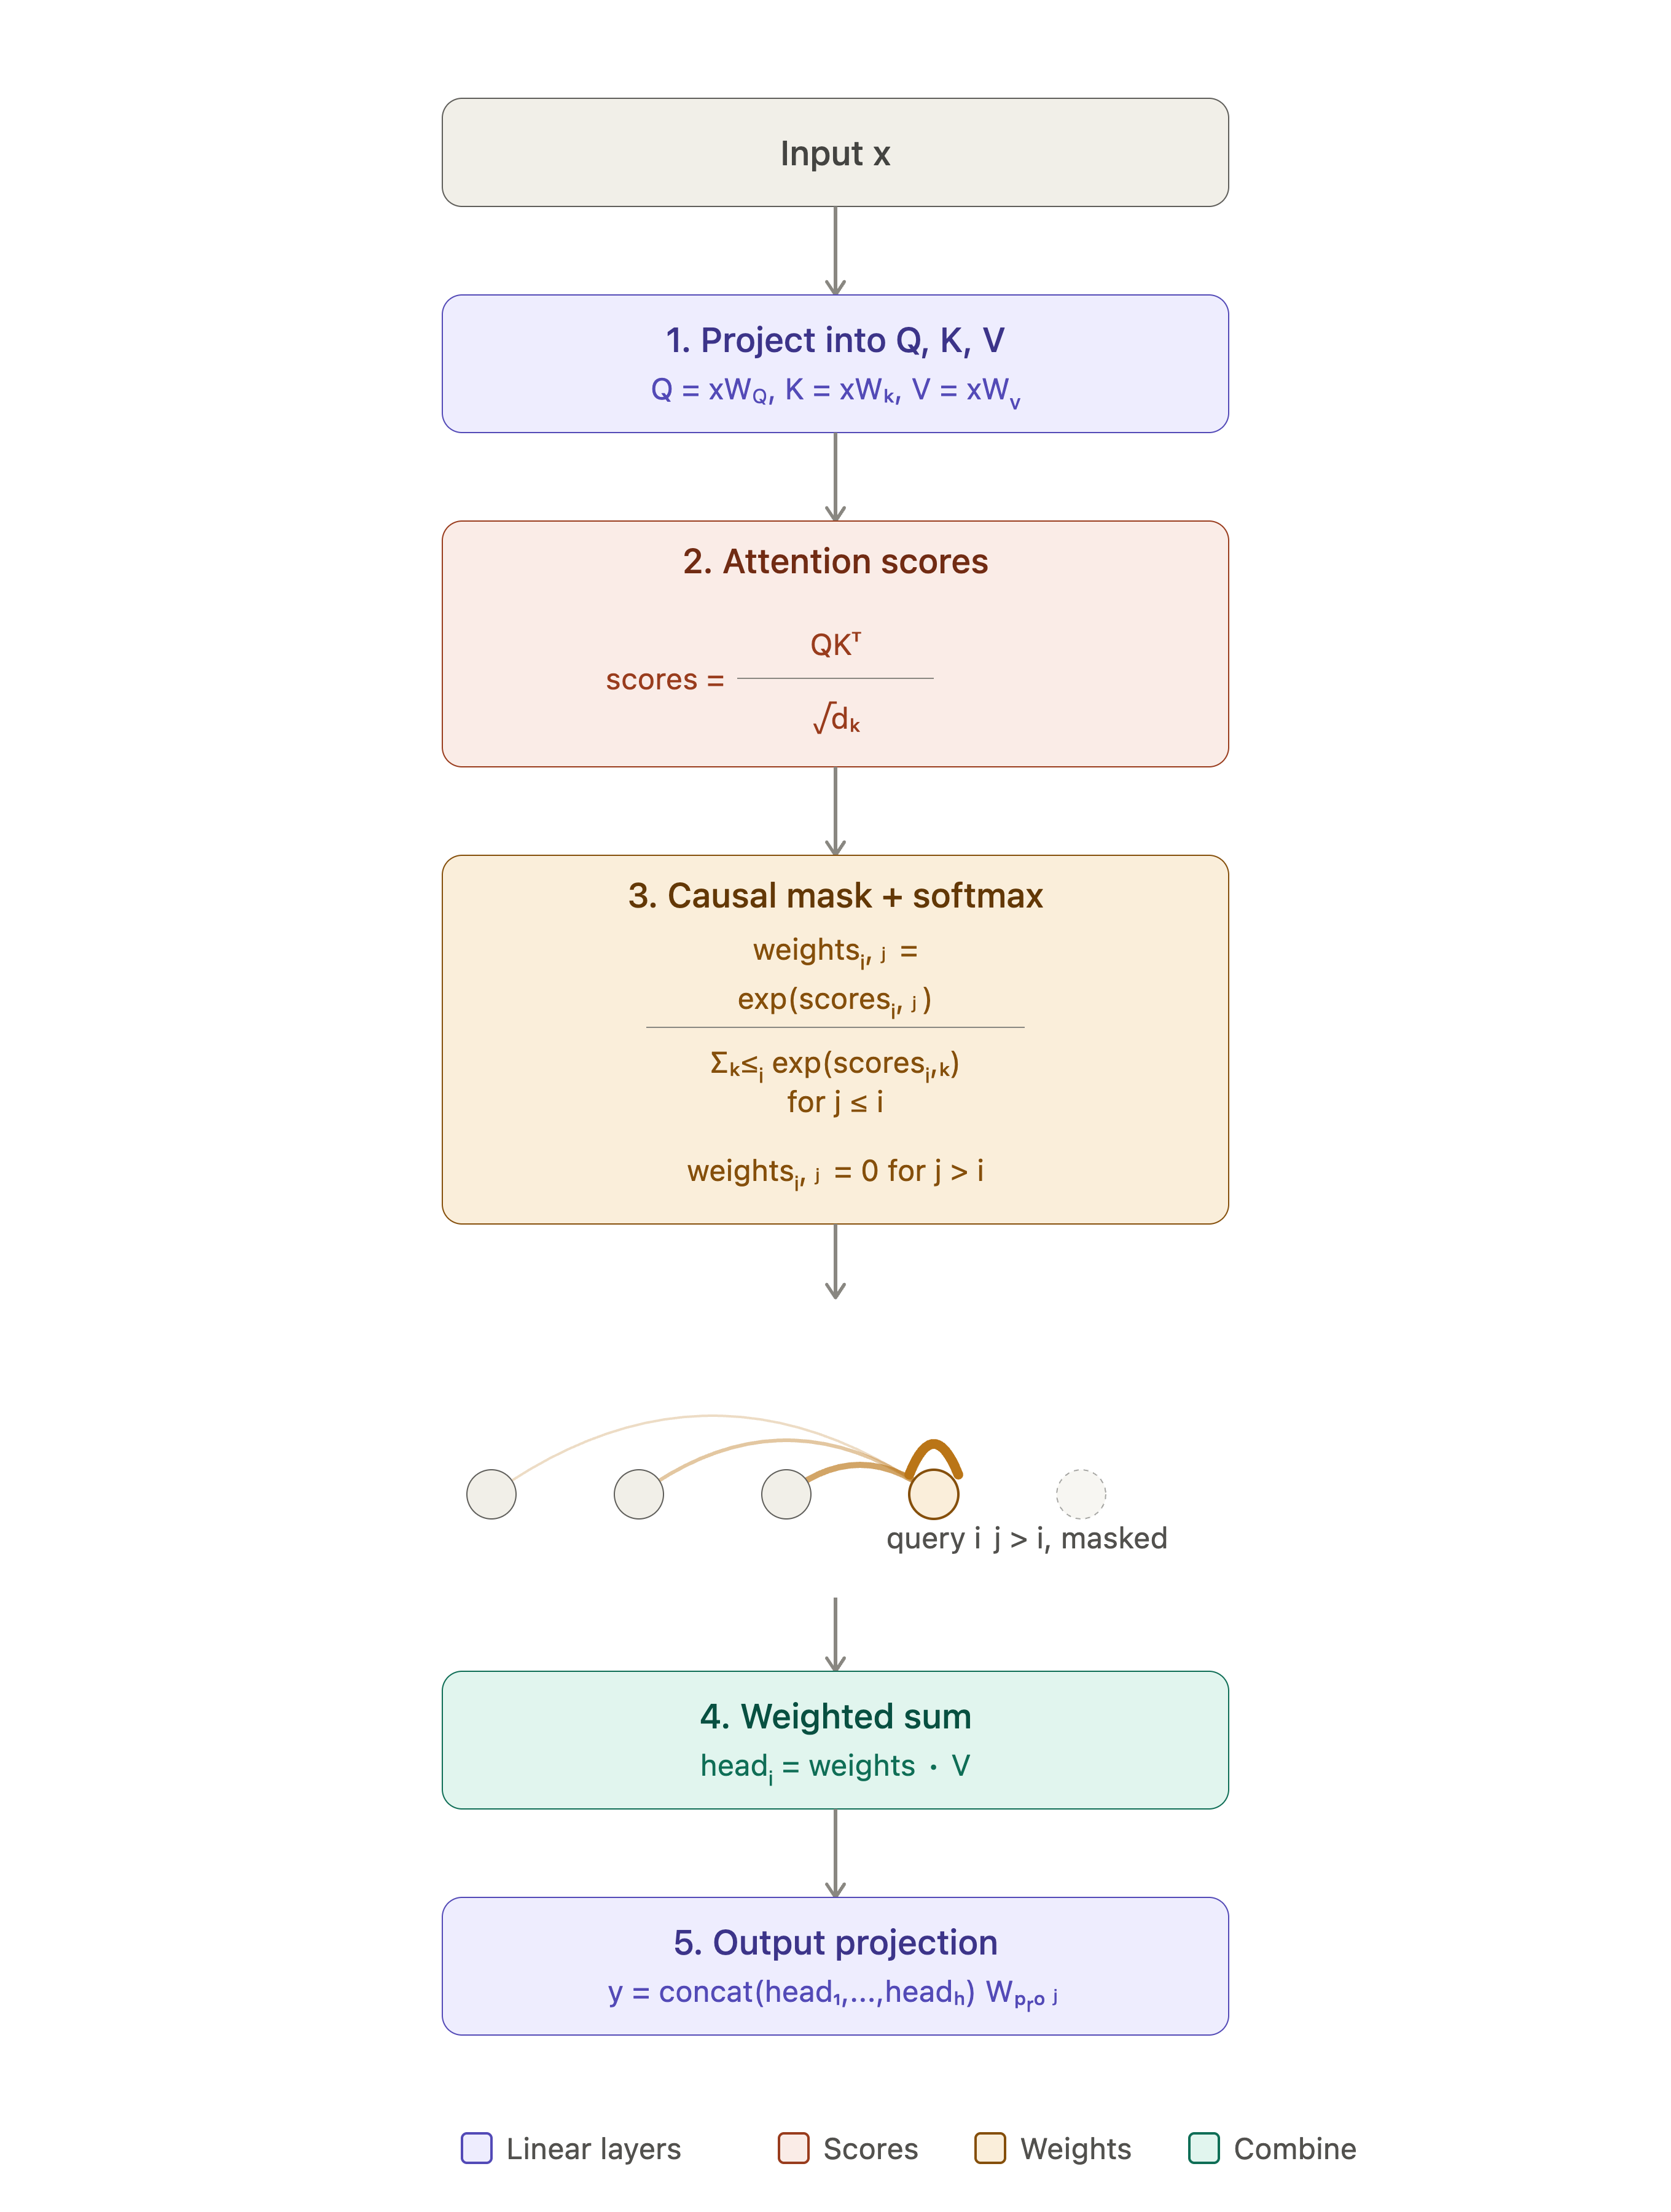


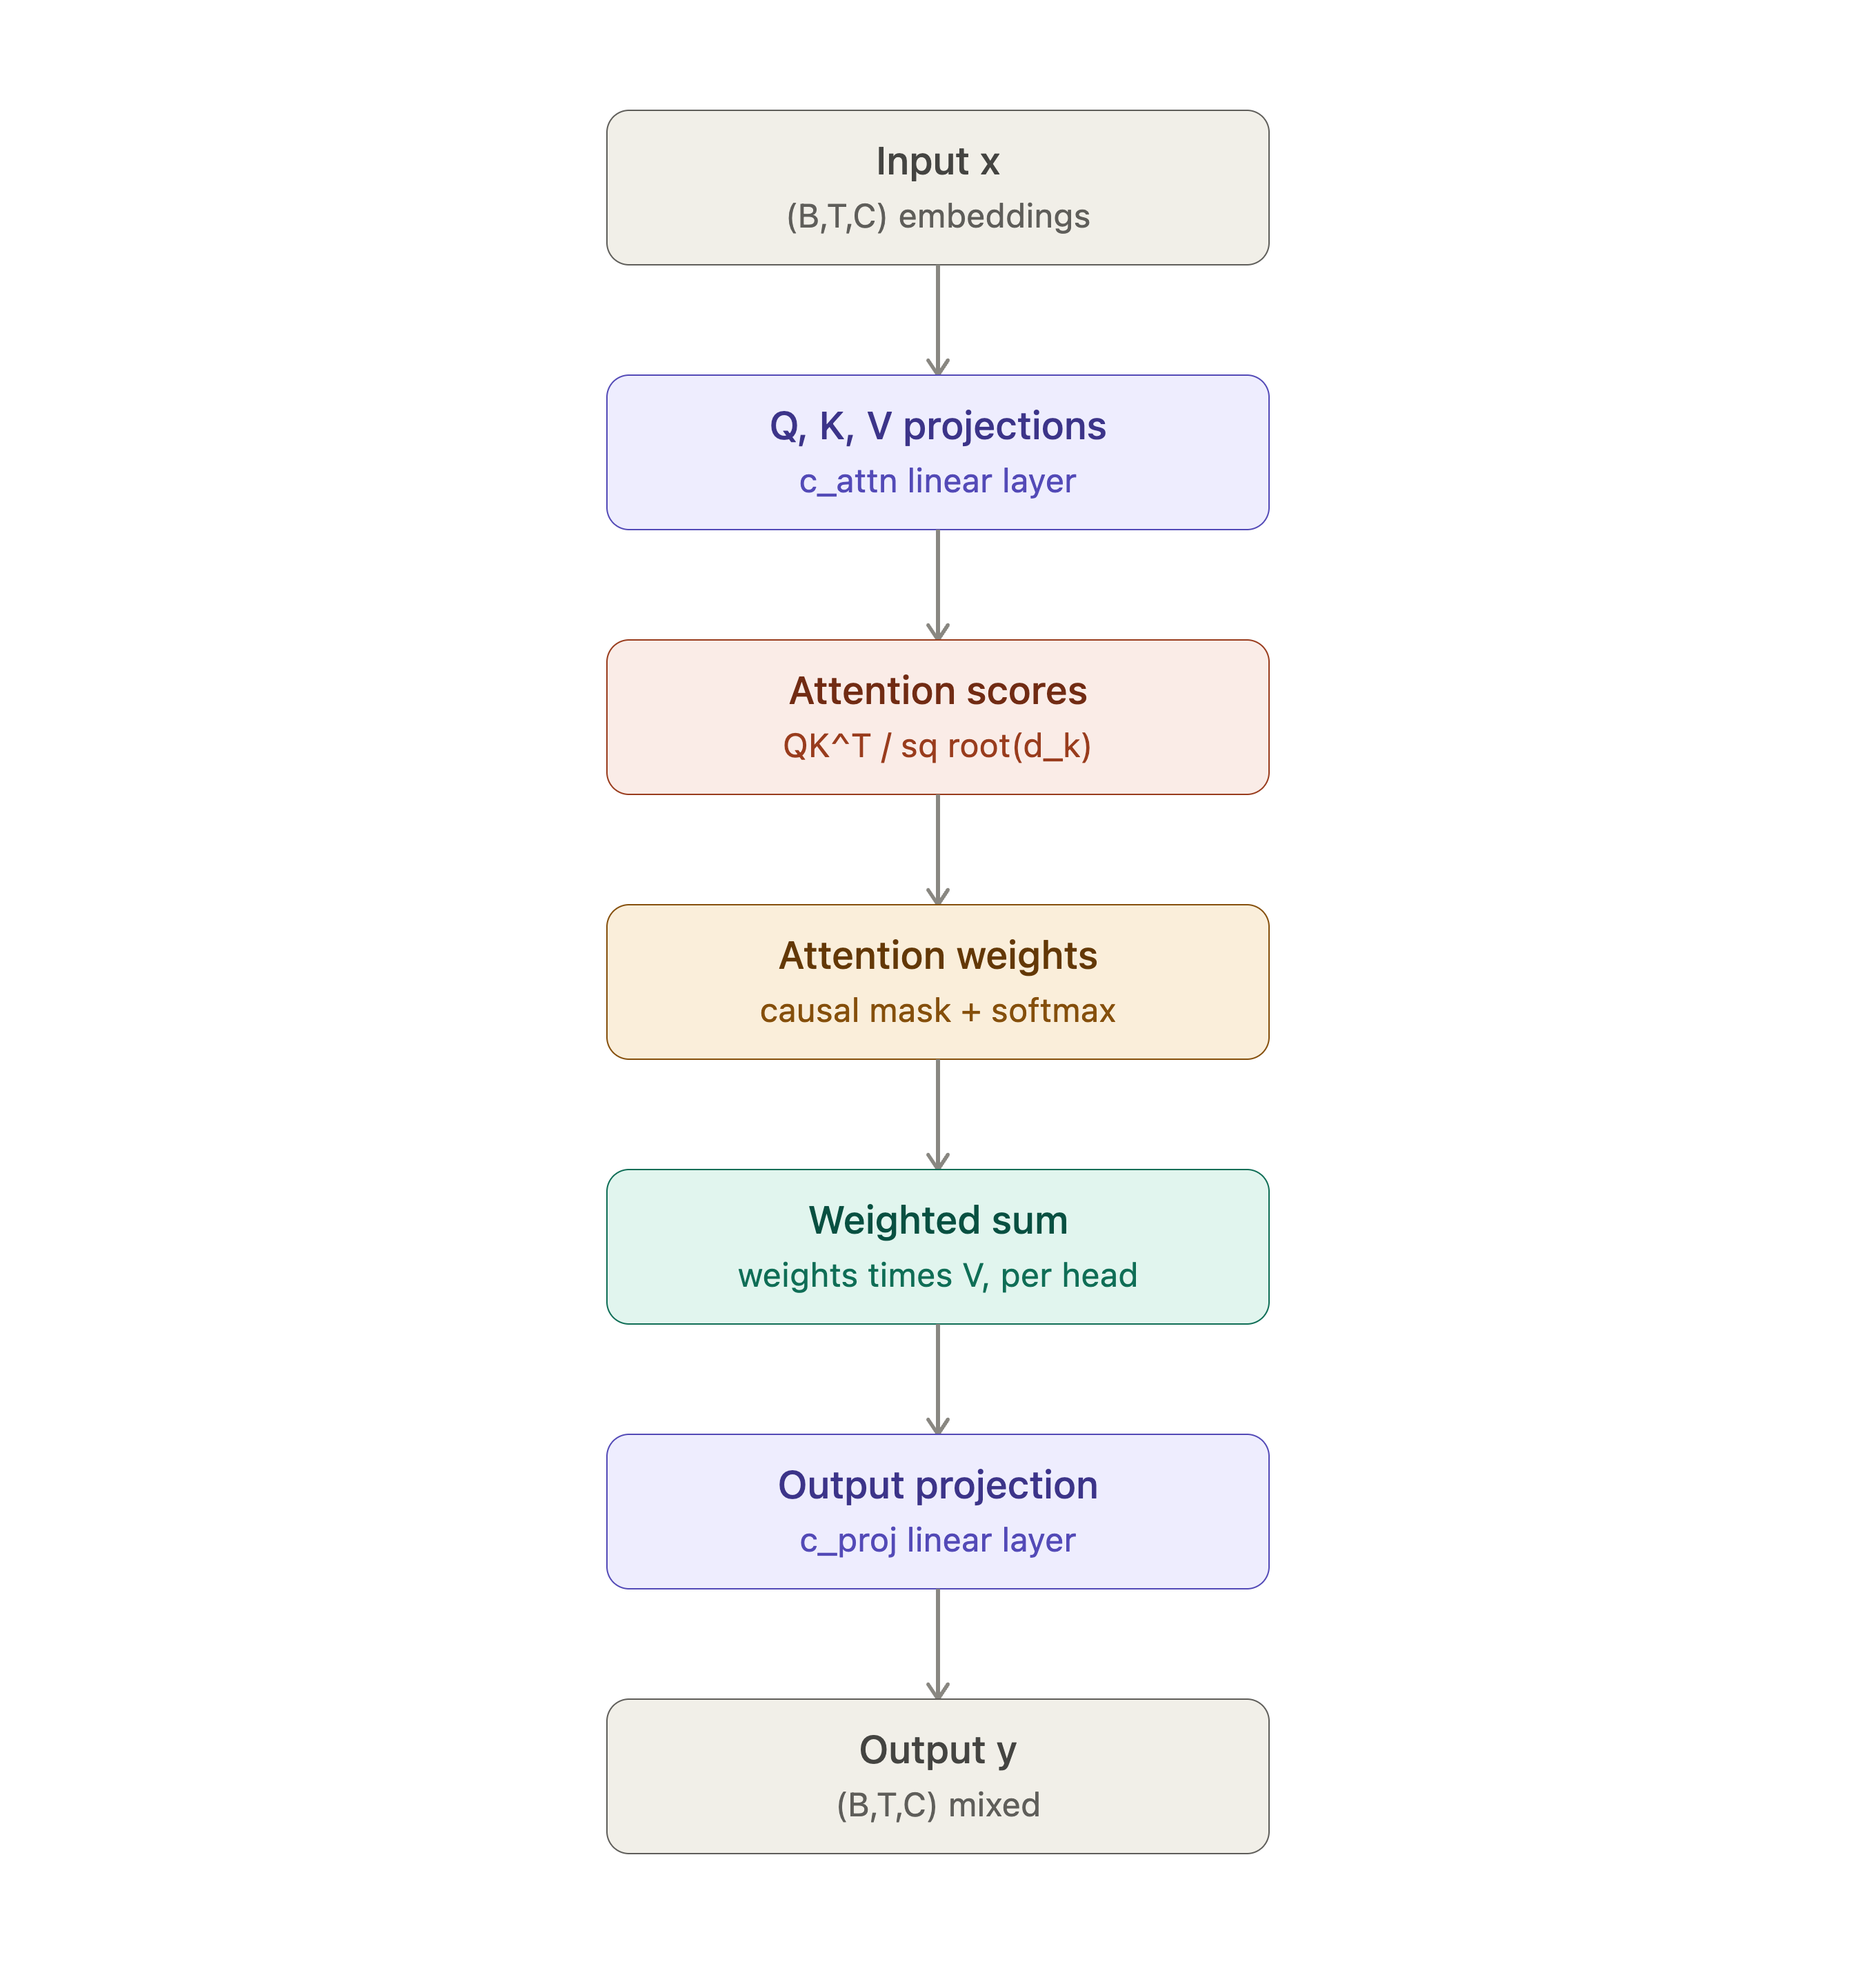

In [13]:
# Actual attention mechanism
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0 # emb_dim must divide evenly across all heads
        
        # 1 single linear layer projects input into Q,K,V all concatenated.
        # Efficiency trick to multiply 1 big matrix instead of 3
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        
        # output projection, after attention is computed, to mix information back down to emb dim(n_embd);
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias) # concta_head * W_O
        
        # randomly zero out some attention weights/ outputs values during training to reduce overfitting; 
        self.attn_dropout = nn.Dropout(config.dropout) 
        self.resid_dropout = nn.Dropout(config.dropout)
        
        self.n_head = config.n_head
        self.n_embd = config.n_embd

        # check PyTorch version Flash Attention kernel built in, use that(memory eff) else use manual;
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            # isn't a trainable param
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, seq length(time steps), emb dim from input x ex: (4, 8, 512);
        
        # splits the result back into 3 seperate q,k,v tensors i'e from (B,T,3C) -> (B,T,C);
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2) # split along dim=2 i.e C;

        # (B,T,C) -> (B,T,n_head, dim_per_head) then transpose dim (1,2) -> (B, n_head, T, dim_per_head)
        # splitting emb dimention into multiple heads, so each head can attend independently;
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            #  is_casual asks to use pyTorch's flash attention;
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                              dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else: # manula fallback
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1))) # scaled attention score
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf')) # apply casual mask
            att = F.softmax(att, dim=-1) # score -> prob
            att = self.attn_dropout(att) # regularization
            y = att @ v # actual attention output;
            
        # reshape back from (B, n_head, T, dim_per_head) to (B, T, C);
        y = y.transpose(1, 2).contiguous().view(B, T, C) 
        y = self.resid_dropout(self.c_proj(y)) # dropout before adding this o/p to a residual connection
        return y

### MLP Pipeline:

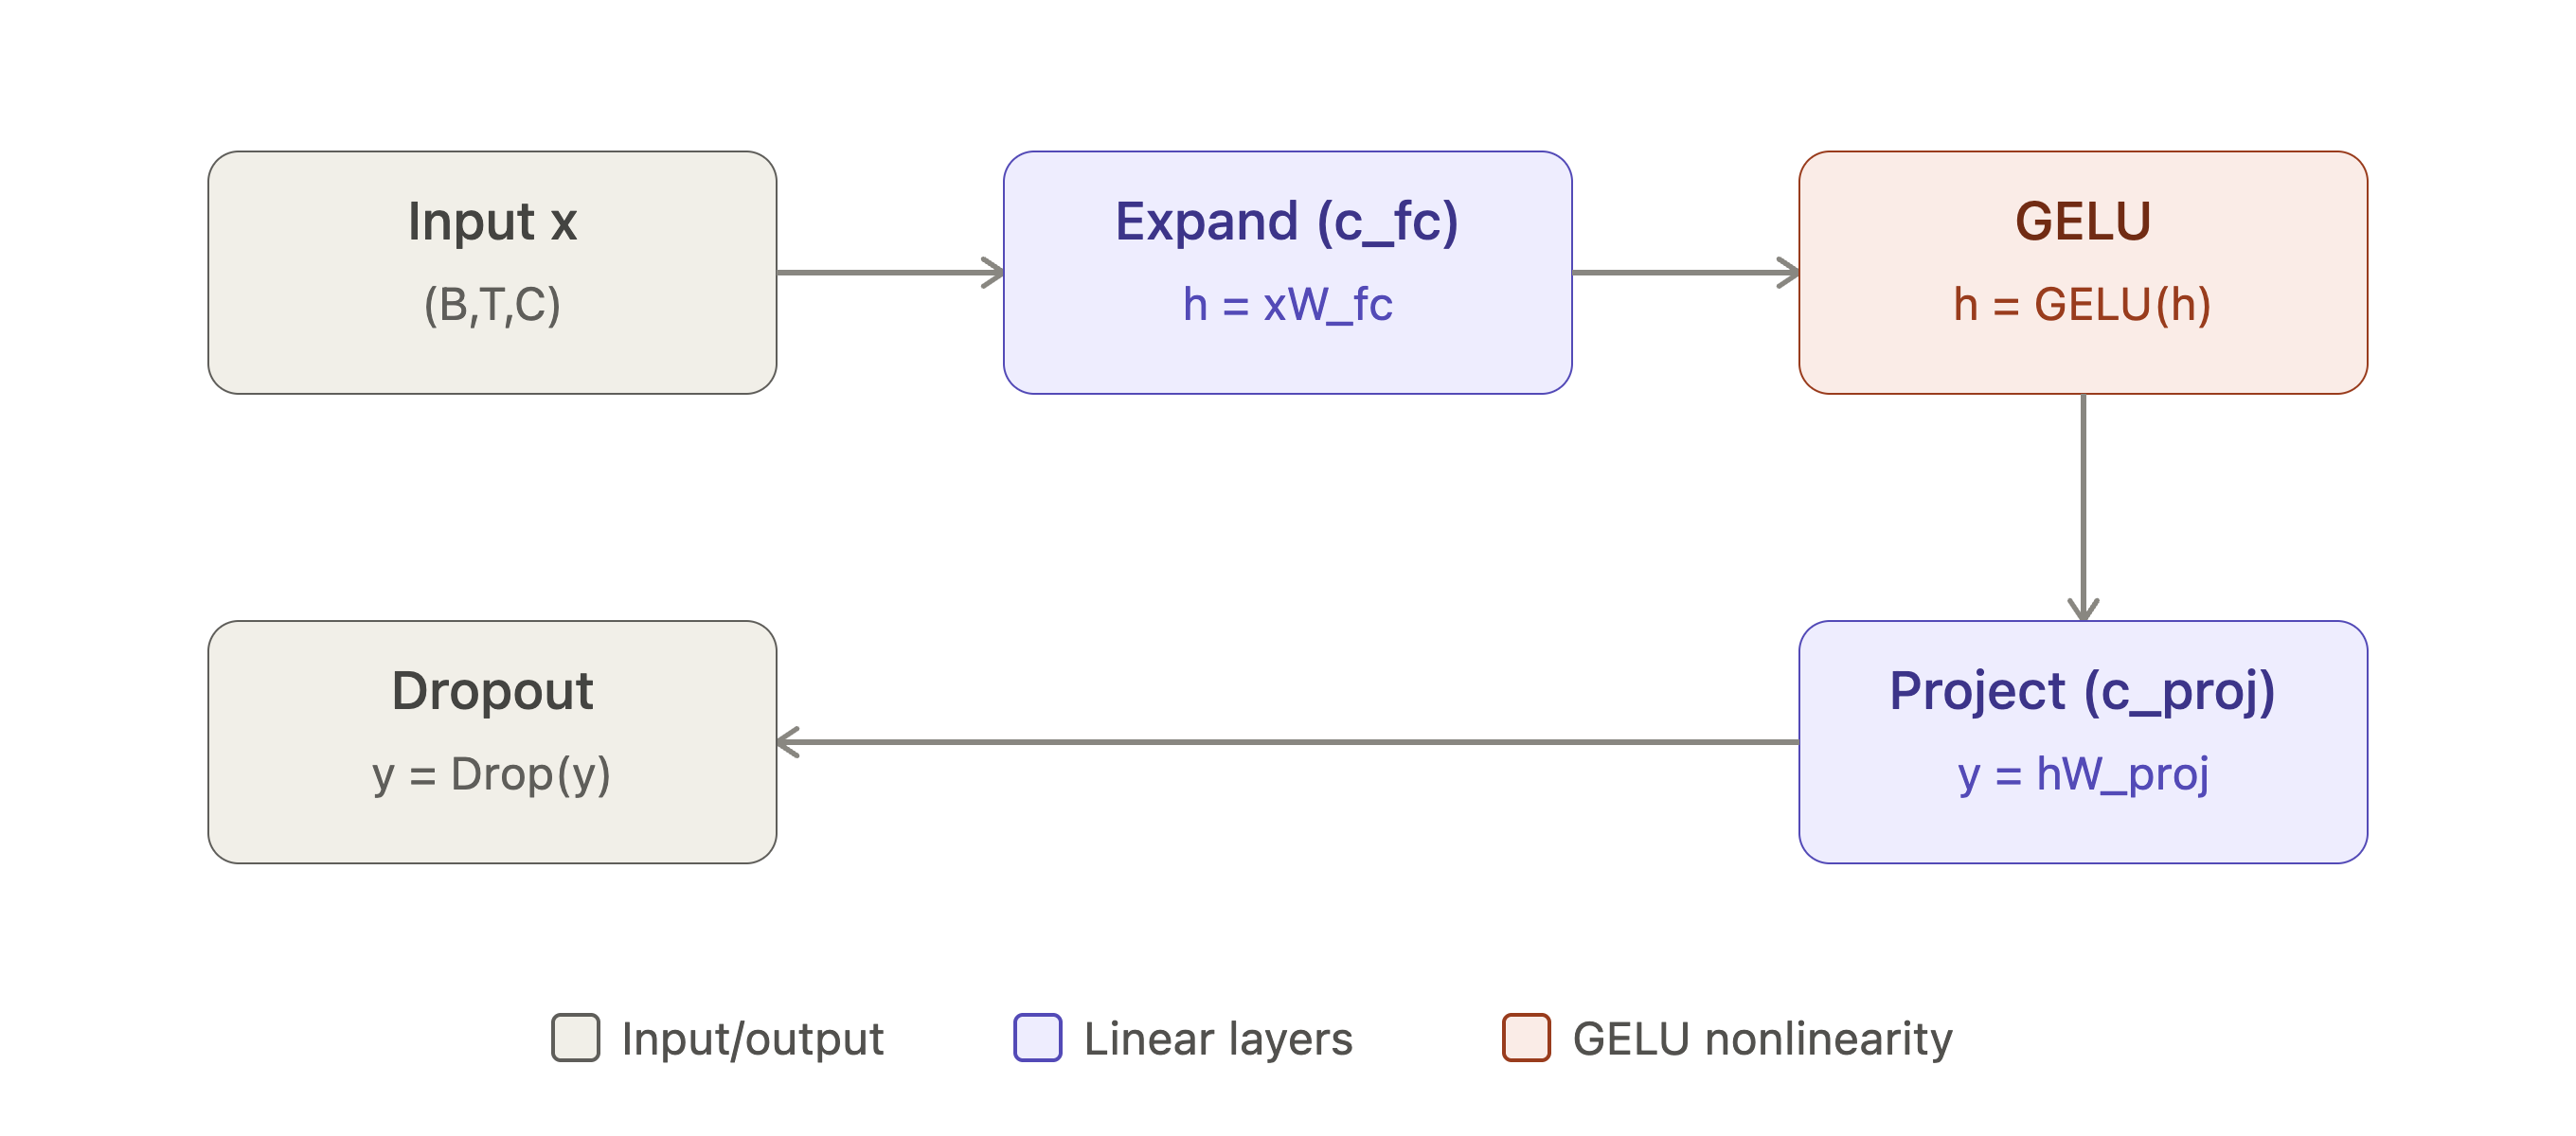

In [14]:
# Attention let's tokens share info with each other;
# MLP then processes each token's info individually; adding capacity for more complex transformations;
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # expand hidden layer 4X
        self.gelu = nn.GELU() # smooth non-linear activation func(softer alternative to ReLU) applied elem-wise;
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # contract back from 4X;
        self.dropout = nn.Dropout(config.dropout) # regularization
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

### Block Visual Understanding:

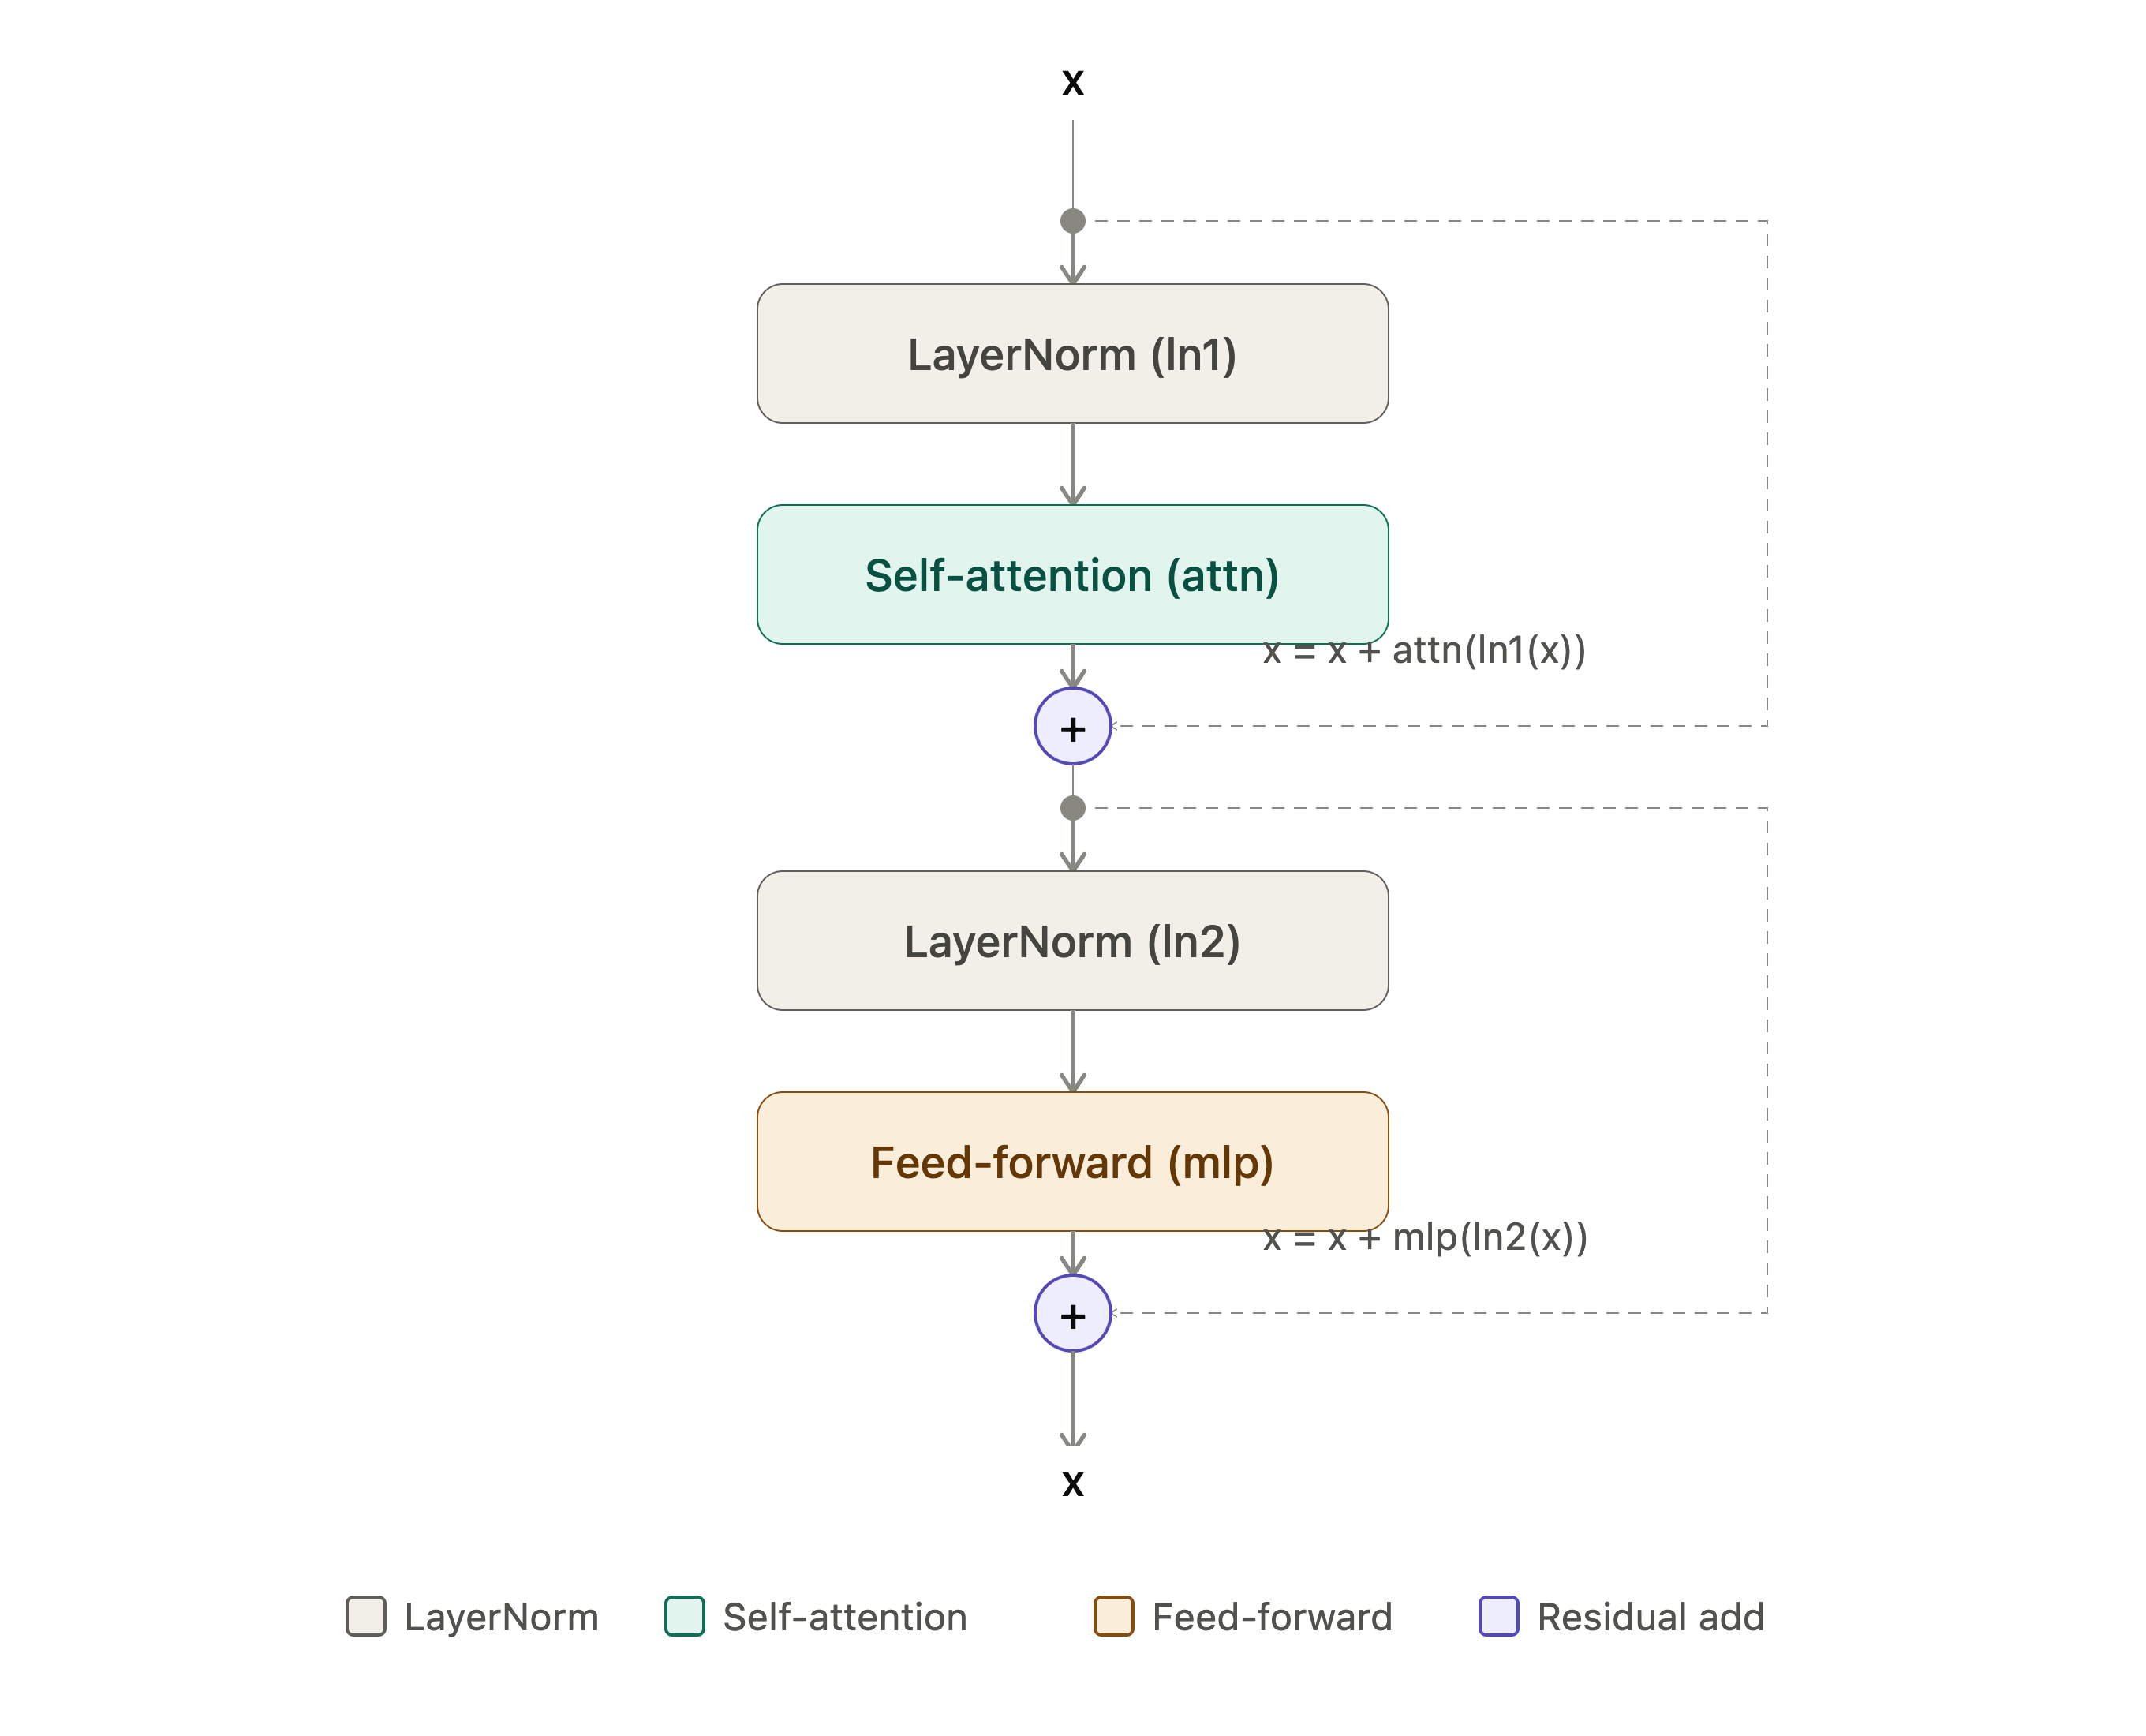

In [15]:
# A full GPT is just the copies of this block stacked in sequence;
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    # shortcut connection(x + f(x) instead of f(x)) they let grads flow directly;
    # Which makes stacking pssbl without unstable training;
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

In [16]:
# GPT config: Bundlign all hyperparameters
@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int # 50257 for gpt2's tokenizer
    n_layer: int # no. of blocks to stack
    n_head: int # no. of heads per block
    n_embd: int 
    dropout: float = 0.0
    bias: bool = True

In [17]:
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd), # word token emb
            wpe=nn.Embedding(config.block_size, config.n_embd), # word position emb
            drop=nn.Dropout(config.dropout), # aplied after combining token
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # actual stack of n layers
            
            # one final LayerNorm after all blocks before producing logits;
            ln_f=LayerNorm(config.n_embd, config.bias), 
        ))
        # projecting from emb_dim to vocab_size;
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        
        # Weight tying: this amkes i/p emb matrix an do/p proj matrix the same tensors; 
        # reduces approx half parameters improve quality as same space used for reading and writing;
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights) # apply init weights recursively to all modules;

        # re-init each c_proj weights with even smaller std dev(trick from gpt2); keeps overall grads stable;
        for pn, p in self.named_parameters(): 
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size() # idx is the x the get_batch produces

        # safety check: can't feed seq length longer than model's context window;
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device) # builds position indices [0,1...,t-1];

        # looks up embedding vectors for tokens and position
        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        
        x = self.transformer.drop(tok_emb + pos_emb) # get input emb
        # loops x sequentially to every transformer block;
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x) # final normalization before producing outputs;

        # Training mode
        if targets is not None:
            logits = self.lm_head(x) # logits: raw score over full vocab;
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        # Inference/generation mode
        else:
            logits = self.lm_head(x[:, [-1], :]) # only computes logits for last position;
            return logits, None

    # Actually producing text here;
    @torch.no_grad() # disable grad tracking
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            # truncate to only last block tokens if the idx size inc;
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond) # get logit for next position;
            logits = logits[:, -1, :] / temperature # temp<1 (sharpens distri/ connfident)
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1))) #(topK val,their indices) -1->vocab_size
                logits[logits < v[:, [-1]]] = -float('Inf') # other than top k prob set to -inf;
            probs = F.softmax(logits, dim=-1) # filtered logits -> prob distribution;
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1) # append newly generated token to current seq;
        return idx # orgnl + all newly generated tokens;

In [18]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or any context size you're training with gpt2 had 1024;
    n_layer=6,            # no. of stacked transformers
    n_head=6,             # attention heads per block
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

## Step 5: Define the loss function

In [21]:
# Averaging loss over many batches for both traina nd val giving more stable loss to track while training;
def estimate_loss(model):
    out = {} # holds final avg loss for each split
    model.eval() # switched model to eval mode; as nn.Dropout does reg in training mode not eval;
    with torch.inference_mode(): # diables grad tracking
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters) # preallocates small tensor to hold eval_iters
            for k in range(eval_iters):
                X, Y = get_batch(split) # random sampling of batch
                with ctx: # same context manager used during training
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train() # switched model back to training mode
    return out

## Step 6: Define SLM Training Configuration Part 1

In [22]:
# imports
import torch
from contextlib import nullcontext

In [30]:
# Training Config

learning_rate = 1e-4 # more stable training, earlier 1e-4
max_iters = 20000 # decrease from 25000
warmup_steps = 1000 # smoother initial train, earlier 100; steps till when lr grow from min to it's val;
min_lr = 1e-5 # lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 # changed from 64, capture longer range dependencies
gradient_accumulation_steps = 32 # reduced from 50

In [27]:
device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast

In [28]:
# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky

dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

#  on CPU this context manager is no-op and on GPU it wraps the forward pass;
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype) 

In [29]:
torch.set_default_device(device) # moves recent tensors all to device;
torch.manual_seed(42) # for reproducability

## Step 7: Define SLM Training Configuration Part 2

In [32]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

## BETA1(the mean of grads- momentum), CHANGED BETA2(variance of grad- adaptive scaling) to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, start_factor=1e-3, total_iters = warmup_steps) # Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) # Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.amp.GradScaler('cuda', enabled=(dtype == 'float16'))

## Step 8: Pre-train the SLM

In [33]:
best_val_loss = float('inf') # start loss as infinitely bad;
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device) # moves every parameter and buffer onto the target device;

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}") # visually confirm warmup/decay;
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        # keeping the best checkpoints of model training;
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx: # wraps frwd pass in autocast is on CUDA or does nothing for CPU;
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps # ensuring avg grad;
        scaler.scale(loss).backward() # to prevent underflow;

    #  only enter when a complete batch grads are accumulated;
    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 500: train loss 9.7870, val loss 9.7855
The current learning rate: 0.00005
Epoch 1000: train loss 8.8486, val loss 8.8440
The current learning rate: 0.00010
Epoch 1500: train loss 7.8067, val loss 7.8037
The current learning rate: 0.00010
Epoch 2000: train loss 6.8847, val loss 6.8863
The current learning rate: 0.00010
Epoch 2500: train loss 6.1492, val loss 6.1406
The current learning rate: 0.00010
Epoch 3000: train loss 5.6073, val loss 5.6119
The current learning rate: 0.00010
Epoch 3500: train loss 5.1709, val loss 5.1705
The current learning rate: 0.00010
Epoch 4000: train loss 4.8453, val loss 4.8405
The current learning rate: 0.00009
Epoch 4500: train loss 4.6035, val loss 4.6023
The current learning rate: 0.00009
Epoch 5000: train loss 4.3936, val loss 4.3828
The current learning rate: 0.00009
Epoch 5500: train loss 4.2255, val loss 4.2199
The current learning rate: 0.00009
Epoch 6000: train loss 4.0731, val loss 4.0704
The current learning rate: 0.00009
Epoch 6500: train

## Step 9: Plot the SLM Loss Function

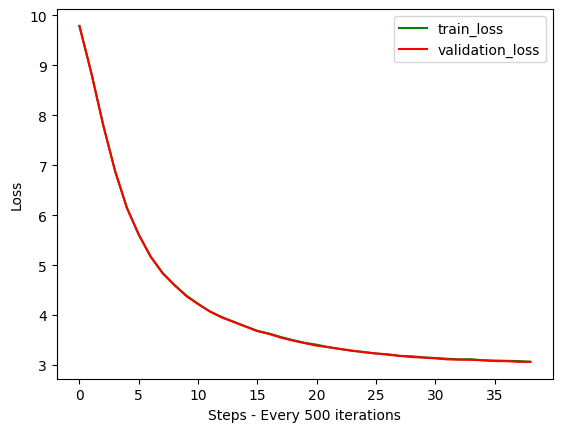

In [34]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel(f"Steps - Every {eval_iters} iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Step 10: Run SLM Inference on our trained model

In [35]:
#Load the model
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states
model = model.to(device) # load model on active device;
model.eval() # run inference on trained model in eval mode;

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 384)
    (wpe): Embedding(128, 384)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x Block(
        (ln1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=384, out_features=1152, bias=True)
          (c_proj): Linear(in_features=384, out_features=384, bias=True)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=384, out_features=1536, bias=True)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=1536, out_features=384, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (lm_head): Linear(in_features=384, out_features=50257, bias=False)
)

In [36]:
sentence = "Once upon a time there was a pumpkin."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0)).to(device)
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. The plant loved to play in the yard. One day, theding on the field was a old fairy namedimiy. She picked up the sink andDaniely.
"iao," painful mom said. "You will14 One day, heard a into a treasure, thunder. Chris dessert as great than a worm played with theella!
Anna's mom came to be careful and said, "That tricks. I show you make you said so angry andemo away am far high for joy."
His mom and busyie learned to be if it could why we have examined the special star sayTan a famous eyes. 
Butkingers tried to show one farm, then he wanted. 
"Anna looked and asked not know what he felt better. 
The duck replied, "Let's play around the flowers and getting win. You insured don't be very pretty and pain." But let her how to load, Anna and Ben shared the92 and friendsching the rad


In [37]:
sentence = "A little girl went to the woods"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0)).to(device)
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A little girl went to the woods. She understood can get high and Romance promoterons to the plays, music!Once upon a time, there pointing for a little girl named Lucy. Lily loved to play with her friends ig accident. shouts, "Hi, mom!"
Sue tried to help her friend, a small girl named Lily. Sue said, "I want best could eat worm would talk and walk!" Lucy was so happy that she opened the pigs, and they played together in the kitchen.
Then, Lucy and her mom were very cute. rocks and his friends looked and smiled. Sara and said, "You are doing, ends. I will be embarrassed and everyone amazing. I can run to eat now." Lucy and Lily thanked her. They all played with the fragile home. They were messy and played had a few was very much fun, cream and they liked to run around for the 0004.Once upon a time, there was a little girl named The girl loved to grow arms. One day, she
